# Early Exit — SimCLR Backbone
Follows the solution structure: 3 exits (after layer2, layer3, layer4).
Backbone weights from SimCLR pretraining. layer2/3/4 fine-tuned jointly with exit heads.

In [96]:
import os, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

Device: mps


### Load Data

In [97]:
train_dir = Path('dataset_ood/train')
val_dir   = Path('dataset_ood/val')
test_dir  = Path('dataset_ood/test')

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(train_dir, transform=train_tfms)
val_ds   = ImageFolder(val_dir,   transform=val_tfms)
test_ds  = ImageFolder(test_dir,  transform=val_tfms)

num_workers = 0 if DEVICE.type == 'mps' else 2
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=num_workers)

num_classes = len(train_ds.classes)
print('Classes:', train_ds.classes)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Classes: ['CORROSION', 'NOCORROSION']
Train: 2522 | Val: 653 | Test: 182


### Model Implementation

In [98]:
import torch.nn.functional as F

# --- Load SimCLR checkpoint and reconstruct backbone ---
class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=None)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )
    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, F.normalize(z, dim=1)

simclr = SimCLR(proj_dim=128)
simclr.load_state_dict(torch.load('simclr_best.pt', map_location='cpu'))
simclr.eval()

# Map SimCLR encoder Sequential → named ResNet18 backbone attributes
enc = list(simclr.encoder.children())
backbone = models.resnet18(weights=None)
backbone.conv1   = enc[0]
backbone.bn1     = enc[1]
backbone.relu    = enc[2]
backbone.maxpool = enc[3]
backbone.layer1  = enc[4]
backbone.layer2  = enc[5]
backbone.layer3  = enc[6]
backbone.layer4  = enc[7]
backbone.avgpool = enc[8]
backbone.fc      = nn.Identity()
backbone = backbone.to(DEVICE)

# Exit heads
exit1_head = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(128, num_classes),
).to(DEVICE)

exit2_head = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(256, num_classes),
).to(DEVICE)

final_head = nn.Linear(512, num_classes).to(DEVICE)

# Freeze all, then unfreeze layer2/3/4
for p in backbone.parameters():
    p.requires_grad = False
for layer in [backbone.layer2, backbone.layer3, backbone.layer4]:
    for p in layer.parameters():
        p.requires_grad = True

def forward_early_exit(x):
    x = backbone.conv1(x)
    x = backbone.bn1(x)
    x = backbone.relu(x)
    x = backbone.maxpool(x)
    x = backbone.layer1(x)
    x = backbone.layer2(x);  exit1_logits = exit1_head(x)
    x = backbone.layer3(x);  exit2_logits = exit2_head(x)
    x = backbone.layer4(x)
    x = backbone.avgpool(x)
    x = torch.flatten(x, 1)
    final_logits = final_head(x)
    return exit1_logits, exit2_logits, final_logits

trainable = sum(p.numel() for p in list(backbone.parameters()) +
               list(exit1_head.parameters()) + list(exit2_head.parameters()) +
               list(final_head.parameters()) if p.requires_grad)
print(f'Trainable params: {trainable:,}')

Trainable params: 11,020,806


### Training Function

In [99]:
def train_model(criterion, optimizer, num_epochs=15, best_path='early_exit_simclr.pt'):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_exit1_acc': [], 'train_exit2_acc': [], 'train_final_acc': [],
        'val_exit1_acc':   [], 'val_exit2_acc':   [], 'val_final_acc':   [],
    }
    best_val_final_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                backbone.train(); exit1_head.train(); exit2_head.train(); final_head.train()
                loader = train_loader
            else:
                backbone.eval();  exit1_head.eval();  exit2_head.eval();  final_head.eval()
                loader = val_loader

            running_loss = 0.0
            correct_exit1 = correct_exit2 = correct_final = total = 0

            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    e1, e2, ef = forward_early_exit(inputs)
                    loss = 0.2 * criterion(e1, labels) + 0.3 * criterion(e2, labels) + 1.0 * criterion(ef, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss   += loss.item() * inputs.size(0)
                correct_exit1  += (e1.argmax(1) == labels).sum().item()
                correct_exit2  += (e2.argmax(1) == labels).sum().item()
                correct_final  += (ef.argmax(1) == labels).sum().item()
                total          += labels.size(0)

            n = total
            history[f'{phase}_loss'].append(running_loss / n)
            history[f'{phase}_exit1_acc'].append(correct_exit1 / n)
            history[f'{phase}_exit2_acc'].append(correct_exit2 / n)
            history[f'{phase}_final_acc'].append(correct_final / n)
            print(f'{phase:5s} | loss={running_loss/n:.4f} | exit1={correct_exit1/n:.4f} | exit2={correct_exit2/n:.4f} | final={correct_final/n:.4f}')

            if phase == 'val' and correct_final / n > best_val_final_acc:
                best_val_final_acc = correct_final / n
                torch.save({
                    'backbone':   backbone.state_dict(),
                    'exit1_head': exit1_head.state_dict(),
                    'exit2_head': exit2_head.state_dict(),
                    'final_head': final_head.state_dict(),
                    'class_names': train_ds.classes,
                }, best_path)
        print()

    print('Best val final acc:', best_val_final_acc)
    return history

### Loss / Optimizer

In [100]:
criterion = nn.CrossEntropyLoss()

trainable_params = (
    list(backbone.layer2.parameters()) +
    list(backbone.layer3.parameters()) +
    list(backbone.layer4.parameters()) +
    list(exit1_head.parameters()) +
    list(exit2_head.parameters()) +
    list(final_head.parameters())
)

optimizer = optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)

### Train

In [101]:
history = train_model(criterion=criterion, optimizer=optimizer, num_epochs=15, best_path='early_exit_simclr.pt')

Epoch 1/15
----------
train | loss=0.6393 | exit1=0.5226 | exit2=0.5797 | final=0.8624
val   | loss=0.6696 | exit1=0.6723 | exit2=0.7182 | final=0.8499

Epoch 2/15
----------
train | loss=0.4600 | exit1=0.6197 | exit2=0.7169 | final=0.9425
val   | loss=0.6937 | exit1=0.7259 | exit2=0.7473 | final=0.8499

Epoch 3/15
----------
train | loss=0.4050 | exit1=0.6531 | exit2=0.7764 | final=0.9607
val   | loss=0.6733 | exit1=0.7305 | exit2=0.7611 | final=0.8683

Epoch 4/15
----------
train | loss=0.3534 | exit1=0.6753 | exit2=0.8013 | final=0.9758
val   | loss=0.6627 | exit1=0.7320 | exit2=0.7596 | final=0.8760

Epoch 5/15
----------
train | loss=0.3465 | exit1=0.7121 | exit2=0.8315 | final=0.9722
val   | loss=0.7148 | exit1=0.7335 | exit2=0.7718 | final=0.8637

Epoch 6/15
----------
train | loss=0.3097 | exit1=0.7292 | exit2=0.8418 | final=0.9798
val   | loss=0.7503 | exit1=0.7305 | exit2=0.7887 | final=0.8423

Epoch 7/15
----------
train | loss=0.3026 | exit1=0.7387 | exit2=0.8596 | final=0.

### Training History Plots

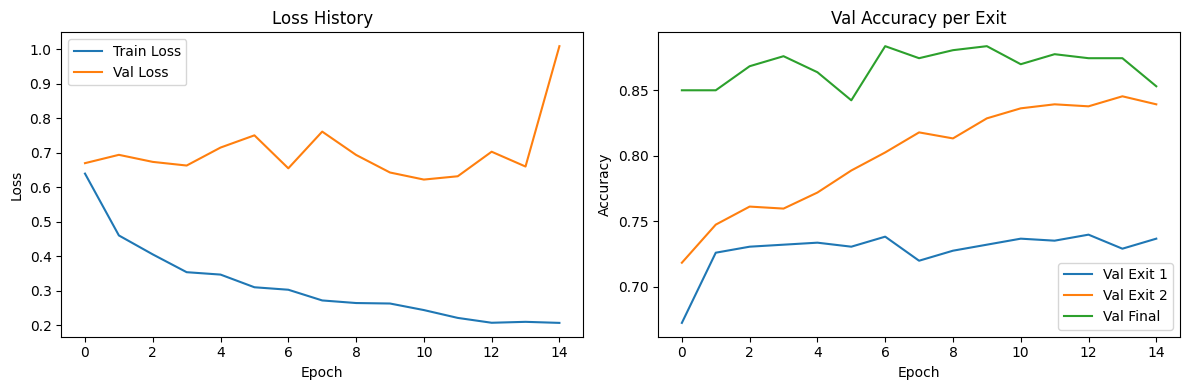

In [102]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(history['val_exit1_acc'], label='Val Exit 1')
plt.plot(history['val_exit2_acc'], label='Val Exit 2')
plt.plot(history['val_final_acc'], label='Val Final')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Val Accuracy per Exit')

plt.tight_layout(); plt.savefig('simclr_ee_history.png', dpi=150); plt.show()

### Multi-Exit Routing

In [103]:
# Load best checkpoint
ckpt = torch.load('early_exit_simclr.pt', map_location=DEVICE)
backbone.load_state_dict(ckpt['backbone'])
exit1_head.load_state_dict(ckpt['exit1_head'])
exit2_head.load_state_dict(ckpt['exit2_head'])
final_head.load_state_dict(ckpt['final_head'])

def evaluate_routed_inference(dataloader, tau1=0.90, tau2=0.90):
    backbone.eval(); exit1_head.eval(); exit2_head.eval(); final_head.eval()
    total = correct = exit1_count = exit2_count = final_count = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            e1, e2, ef = forward_early_exit(inputs)

            p1 = torch.softmax(e1, 1); c1, pred1 = p1.max(1)
            p2 = torch.softmax(e2, 1); c2, pred2 = p2.max(1)
            predf = ef.argmax(1)

            batch_preds = []
            for i in range(labels.size(0)):
                if   c1[i] >= tau1: pred = pred1[i]; exit1_count += 1
                elif c2[i] >= tau2: pred = pred2[i]; exit2_count += 1
                else:               pred = predf[i]; final_count += 1
                batch_preds.append(pred.item())

            batch_preds = torch.tensor(batch_preds, device=labels.device)
            correct += (batch_preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(batch_preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    print(f'Accuracy: {acc:.4f} | Exit1: {exit1_count/total:.4f} | Exit2: {exit2_count/total:.4f} | Final: {final_count/total:.4f}')
    return acc, exit1_count/total, exit2_count/total, final_count/total, all_preds, all_labels

routed_acc, r1, r2, rf, routed_preds, routed_labels = evaluate_routed_inference(test_loader, tau1=0.90, tau2=0.90)

Accuracy: 0.8901 | Exit1: 0.0000 | Exit2: 0.2033 | Final: 0.7967


### Threshold Sweep

In [104]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
simclr_results = []

for tau in thresholds:
    acc, r1, r2, rf, _, _ = evaluate_routed_inference(test_loader, tau1=tau, tau2=tau)
    simclr_results.append((tau, acc, r1, r2, rf))
    print()

Accuracy: 0.7857 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.7857 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.7857 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.7857 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.7857 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.8516 | Exit1: 0.7033 | Exit2: 0.2582 | Final: 0.0385

Accuracy: 0.9176 | Exit1: 0.4945 | Exit2: 0.3407 | Final: 0.1648

Accuracy: 0.9176 | Exit1: 0.2418 | Exit2: 0.4560 | Final: 0.3022

Accuracy: 0.9121 | Exit1: 0.0659 | Exit2: 0.5385 | Final: 0.3956

Accuracy: 0.8956 | Exit1: 0.0000 | Exit2: 0.5165 | Final: 0.4835

Accuracy: 0.8901 | Exit1: 0.0000 | Exit2: 0.4341 | Final: 0.5659

Accuracy: 0.8901 | Exit1: 0.0000 | Exit2: 0.3571 | Final: 0.6429

Accuracy: 0.8901 | Exit1: 0.0000 | Exit2: 0.2033 | Final: 0.7967

Accuracy: 0.8901 | Exit1: 0.0000 | Exit2: 0.0549 | Final: 0.9451



### Confusion Matrices

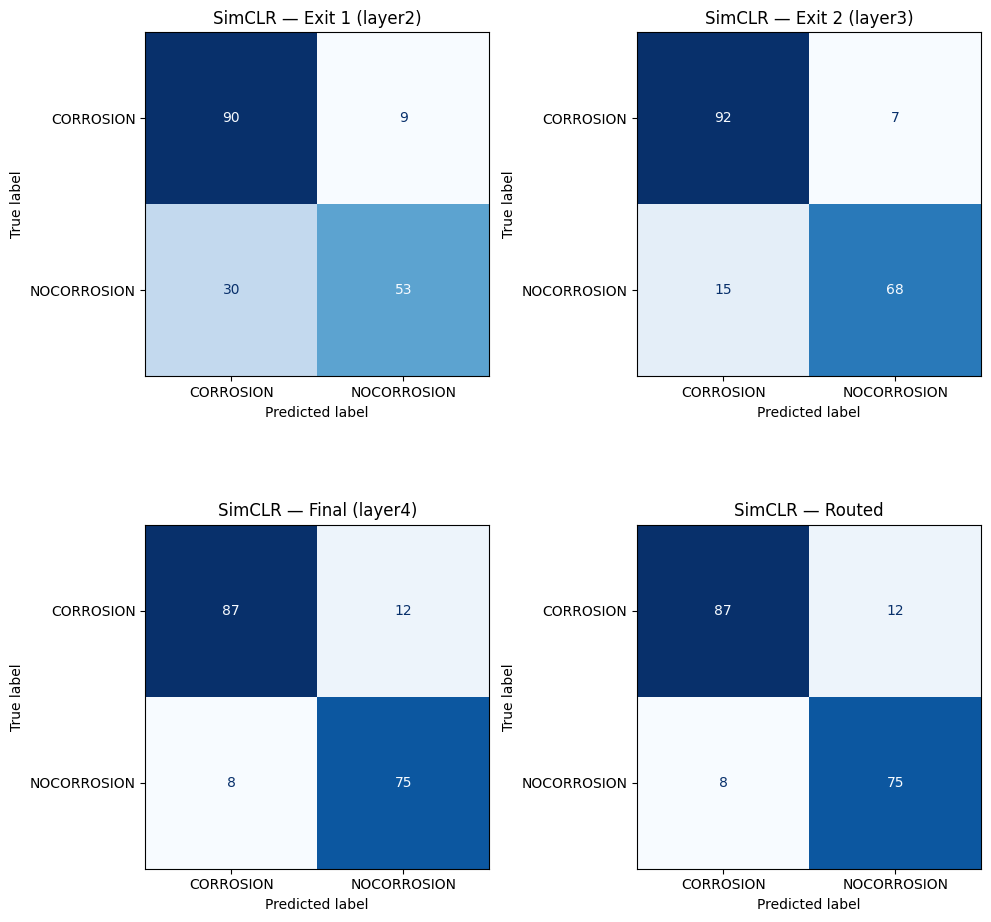

In [105]:
def get_all_exit_predictions(dataloader, tau1=0.90, tau2=0.90):
    backbone.eval(); exit1_head.eval(); exit2_head.eval(); final_head.eval()
    y_true, y_exit1, y_exit2, y_final, y_routed = [], [], [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            e1, e2, ef = forward_early_exit(inputs)
            p1 = torch.softmax(e1, 1); c1, pred1 = p1.max(1)
            p2 = torch.softmax(e2, 1); c2, pred2 = p2.max(1)
            predf = ef.argmax(1)

            routed = []
            for i in range(labels.size(0)):
                if   c1[i] >= tau1: routed.append(pred1[i].item())
                elif c2[i] >= tau2: routed.append(pred2[i].item())
                else:               routed.append(predf[i].item())

            y_true.extend(labels.cpu().numpy())
            y_exit1.extend(pred1.cpu().numpy())
            y_exit2.extend(pred2.cpu().numpy())
            y_final.extend(predf.cpu().numpy())
            y_routed.extend(routed)

    return y_true, y_exit1, y_exit2, y_final, y_routed

y_true, y_exit1, y_exit2, y_final, y_routed = get_all_exit_predictions(test_loader, tau1=0.90, tau2=0.90)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for (title, preds, ax) in [
    ('Exit 1 (layer2)', y_exit1, axes[0,0]),
    ('Exit 2 (layer3)', y_exit2, axes[0,1]),
    ('Final (layer4)',  y_final, axes[1,0]),
    ('Routed',          y_routed, axes[1,1]),
]:
    cm = confusion_matrix(y_true, preds)
    ConfusionMatrixDisplay(cm, display_labels=train_ds.classes).plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'SimCLR — {title}')
plt.tight_layout(); plt.savefig('simclr_ee_confusion.png', dpi=150); plt.show()

### Exit Rates and Accuracy vs Threshold

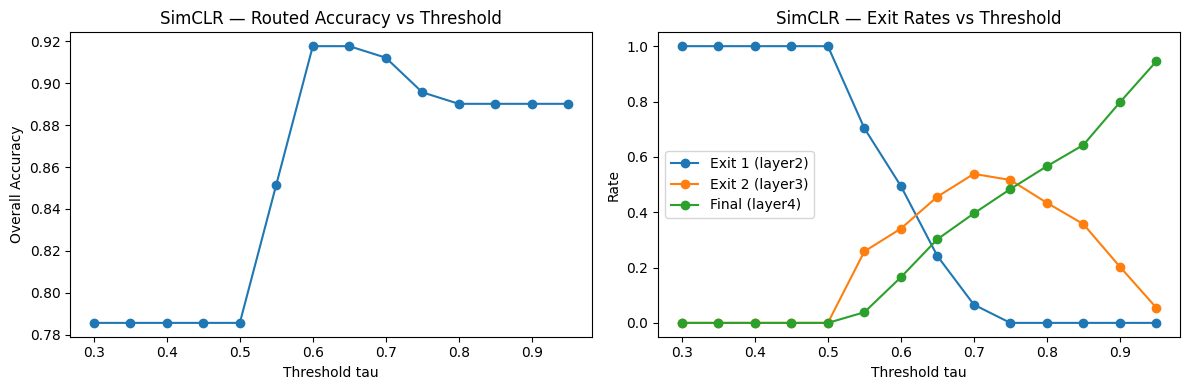

Results saved to simclr_ee_results.json


In [106]:
taus       = [x[0] for x in simclr_results]
accs       = [x[1] for x in simclr_results]
exit1_rates = [x[2] for x in simclr_results]
exit2_rates = [x[3] for x in simclr_results]
final_rates = [x[4] for x in simclr_results]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(taus, accs, marker='o'); plt.xlabel('Threshold tau'); plt.ylabel('Overall Accuracy')
plt.title('SimCLR — Routed Accuracy vs Threshold')

plt.subplot(1, 2, 2)
plt.plot(taus, exit1_rates, marker='o', label='Exit 1 (layer2)')
plt.plot(taus, exit2_rates, marker='o', label='Exit 2 (layer3)')
plt.plot(taus, final_rates, marker='o', label='Final (layer4)')
plt.xlabel('Threshold tau'); plt.ylabel('Rate'); plt.legend()
plt.title('SimCLR — Exit Rates vs Threshold')
plt.tight_layout(); plt.savefig('simclr_ee_rates.png', dpi=150); plt.show()

# Save results for comparison notebook
import json
with open('simclr_ee_results.json', 'w') as f:
    json.dump(simclr_results, f)
print('Results saved to simclr_ee_results.json')

---
# Section 2 — Supervised Early Exit

# Early Exit — Supervised Backbone
3 exits (after layer2, layer3, layer4).
Backbone weights from supervised full fine-tuning. layer2/3/4 further fine-tuned jointly with exit heads.

In [107]:
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

Device: mps


### Load Data

In [108]:
train_dir = Path('dataset_ood/train')
val_dir   = Path('dataset_ood/val')
test_dir  = Path('dataset_ood/test')

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(train_dir, transform=train_tfms)
val_ds   = ImageFolder(val_dir,   transform=val_tfms)
test_ds  = ImageFolder(test_dir,  transform=val_tfms)

num_workers = 0 if DEVICE.type == 'mps' else 2
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=num_workers)

num_classes = len(train_ds.classes)
print('Classes:', train_ds.classes)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Classes: ['CORROSION', 'NOCORROSION']
Train: 2522 | Val: 653 | Test: 182


### Model Implementation

In [109]:
# Load supervised checkpoint and strip fc head
sup_full = models.resnet18(weights=None)
sup_full.fc = nn.Linear(512, num_classes)
sup_full.load_state_dict(torch.load('sup_best.pt', map_location='cpu'))

backbone = sup_full
backbone.fc = nn.Identity()
backbone = backbone.to(DEVICE)

# Exit heads
exit1_head = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(128, num_classes),
).to(DEVICE)

exit2_head = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(256, num_classes),
).to(DEVICE)

final_head = nn.Linear(512, num_classes).to(DEVICE)

# Freeze all, then unfreeze layer2/3/4
for p in backbone.parameters():
    p.requires_grad = False
for layer in [backbone.layer2, backbone.layer3, backbone.layer4]:
    for p in layer.parameters():
        p.requires_grad = True

def forward_early_exit(x):
    x = backbone.conv1(x)
    x = backbone.bn1(x)
    x = backbone.relu(x)
    x = backbone.maxpool(x)
    x = backbone.layer1(x)
    x = backbone.layer2(x);  exit1_logits = exit1_head(x)
    x = backbone.layer3(x);  exit2_logits = exit2_head(x)
    x = backbone.layer4(x)
    x = backbone.avgpool(x)
    x = torch.flatten(x, 1)
    final_logits = final_head(x)
    return exit1_logits, exit2_logits, final_logits

trainable = sum(p.numel() for p in list(backbone.parameters()) +
               list(exit1_head.parameters()) + list(exit2_head.parameters()) +
               list(final_head.parameters()) if p.requires_grad)
print(f'Trainable params: {trainable:,}')

Trainable params: 11,020,806


### Training Function

In [110]:
def train_model(criterion, optimizer, num_epochs=15, best_path='early_exit_supervised.pt'):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_exit1_acc': [], 'train_exit2_acc': [], 'train_final_acc': [],
        'val_exit1_acc':   [], 'val_exit2_acc':   [], 'val_final_acc':   [],
    }
    best_val_final_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                backbone.train(); exit1_head.train(); exit2_head.train(); final_head.train()
                loader = train_loader
            else:
                backbone.eval();  exit1_head.eval();  exit2_head.eval();  final_head.eval()
                loader = val_loader

            running_loss = 0.0
            correct_exit1 = correct_exit2 = correct_final = total = 0

            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    e1, e2, ef = forward_early_exit(inputs)
                    loss = 0.2 * criterion(e1, labels) + 0.3 * criterion(e2, labels) + 1.0 * criterion(ef, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss   += loss.item() * inputs.size(0)
                correct_exit1  += (e1.argmax(1) == labels).sum().item()
                correct_exit2  += (e2.argmax(1) == labels).sum().item()
                correct_final  += (ef.argmax(1) == labels).sum().item()
                total          += labels.size(0)

            n = total
            history[f'{phase}_loss'].append(running_loss / n)
            history[f'{phase}_exit1_acc'].append(correct_exit1 / n)
            history[f'{phase}_exit2_acc'].append(correct_exit2 / n)
            history[f'{phase}_final_acc'].append(correct_final / n)
            print(f'{phase:5s} | loss={running_loss/n:.4f} | exit1={correct_exit1/n:.4f} | exit2={correct_exit2/n:.4f} | final={correct_final/n:.4f}')

            if phase == 'val' and correct_final / n > best_val_final_acc:
                best_val_final_acc = correct_final / n
                torch.save({
                    'backbone':   backbone.state_dict(),
                    'exit1_head': exit1_head.state_dict(),
                    'exit2_head': exit2_head.state_dict(),
                    'final_head': final_head.state_dict(),
                    'class_names': train_ds.classes,
                }, best_path)
        print()

    print('Best val final acc:', best_val_final_acc)
    return history

### Loss / Optimizer

In [111]:
criterion = nn.CrossEntropyLoss()

trainable_params = (
    list(backbone.layer2.parameters()) +
    list(backbone.layer3.parameters()) +
    list(backbone.layer4.parameters()) +
    list(exit1_head.parameters()) +
    list(exit2_head.parameters()) +
    list(final_head.parameters())
)

optimizer = optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)

### Train

In [112]:
history = train_model(criterion=criterion, optimizer=optimizer, num_epochs=15, best_path='early_exit_supervised.pt')

Epoch 1/15
----------
train | loss=0.4340 | exit1=0.5488 | exit2=0.7284 | final=0.9631
val   | loss=0.6191 | exit1=0.5942 | exit2=0.7565 | final=0.9142

Epoch 2/15
----------
train | loss=0.3705 | exit1=0.5496 | exit2=0.7958 | final=0.9750
val   | loss=0.6369 | exit1=0.5942 | exit2=0.7642 | final=0.9096

Epoch 3/15
----------
train | loss=0.3606 | exit1=0.5607 | exit2=0.8220 | final=0.9754
val   | loss=0.6885 | exit1=0.6769 | exit2=0.7672 | final=0.8836

Epoch 4/15
----------
train | loss=0.3189 | exit1=0.6197 | exit2=0.8374 | final=0.9833
val   | loss=0.6393 | exit1=0.7136 | exit2=0.7948 | final=0.9005

Epoch 5/15
----------
train | loss=0.2913 | exit1=0.6772 | exit2=0.8688 | final=0.9861
val   | loss=0.5945 | exit1=0.7351 | exit2=0.7948 | final=0.9096

Epoch 6/15
----------
train | loss=0.2739 | exit1=0.7335 | exit2=0.8795 | final=0.9881
val   | loss=0.5906 | exit1=0.7397 | exit2=0.8178 | final=0.9127

Epoch 7/15
----------
train | loss=0.2708 | exit1=0.7458 | exit2=0.8747 | final=0.

### Training History Plots

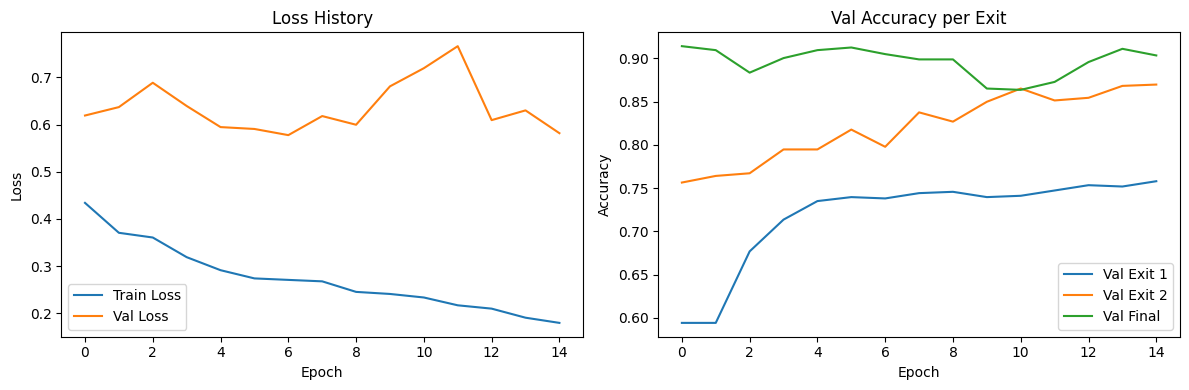

In [113]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(history['val_exit1_acc'], label='Val Exit 1')
plt.plot(history['val_exit2_acc'], label='Val Exit 2')
plt.plot(history['val_final_acc'], label='Val Final')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Val Accuracy per Exit')

plt.tight_layout(); plt.savefig('sup_ee_history.png', dpi=150); plt.show()

### Multi-Exit Routing

In [114]:
ckpt = torch.load('early_exit_supervised.pt', map_location=DEVICE)
backbone.load_state_dict(ckpt['backbone'])
exit1_head.load_state_dict(ckpt['exit1_head'])
exit2_head.load_state_dict(ckpt['exit2_head'])
final_head.load_state_dict(ckpt['final_head'])

def evaluate_routed_inference(dataloader, tau1=0.90, tau2=0.90):
    backbone.eval(); exit1_head.eval(); exit2_head.eval(); final_head.eval()
    total = correct = exit1_count = exit2_count = final_count = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            e1, e2, ef = forward_early_exit(inputs)
            p1 = torch.softmax(e1, 1); c1, pred1 = p1.max(1)
            p2 = torch.softmax(e2, 1); c2, pred2 = p2.max(1)
            predf = ef.argmax(1)

            batch_preds = []
            for i in range(labels.size(0)):
                if   c1[i] >= tau1: pred = pred1[i]; exit1_count += 1
                elif c2[i] >= tau2: pred = pred2[i]; exit2_count += 1
                else:               pred = predf[i]; final_count += 1
                batch_preds.append(pred.item())

            batch_preds = torch.tensor(batch_preds, device=labels.device)
            correct += (batch_preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(batch_preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    print(f'Accuracy: {acc:.4f} | Exit1: {exit1_count/total:.4f} | Exit2: {exit2_count/total:.4f} | Final: {final_count/total:.4f}')
    return acc, exit1_count/total, exit2_count/total, final_count/total, all_preds, all_labels

routed_acc, r1, r2, rf, routed_preds, routed_labels = evaluate_routed_inference(test_loader, tau1=0.90, tau2=0.90)

Accuracy: 0.9341 | Exit1: 0.0000 | Exit2: 0.0000 | Final: 1.0000


### Threshold Sweep

In [115]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
sup_results = []

for tau in thresholds:
    acc, r1, r2, rf, _, _ = evaluate_routed_inference(test_loader, tau1=tau, tau2=tau)
    sup_results.append((tau, acc, r1, r2, rf))
    print()

Accuracy: 0.5440 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.5440 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.5440 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.5440 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.5440 | Exit1: 1.0000 | Exit2: 0.0000 | Final: 0.0000

Accuracy: 0.8022 | Exit1: 0.5385 | Exit2: 0.2088 | Final: 0.2527

Accuracy: 0.9396 | Exit1: 0.0000 | Exit2: 0.1648 | Final: 0.8352

Accuracy: 0.9341 | Exit1: 0.0000 | Exit2: 0.0000 | Final: 1.0000

Accuracy: 0.9341 | Exit1: 0.0000 | Exit2: 0.0000 | Final: 1.0000

Accuracy: 0.9341 | Exit1: 0.0000 | Exit2: 0.0000 | Final: 1.0000

Accuracy: 0.9341 | Exit1: 0.0000 | Exit2: 0.0000 | Final: 1.0000

Accuracy: 0.9341 | Exit1: 0.0000 | Exit2: 0.0000 | Final: 1.0000

Accuracy: 0.9341 | Exit1: 0.0000 | Exit2: 0.0000 | Final: 1.0000

Accuracy: 0.9341 | Exit1: 0.0000 | Exit2: 0.0000 | Final: 1.0000



### Confusion Matrices

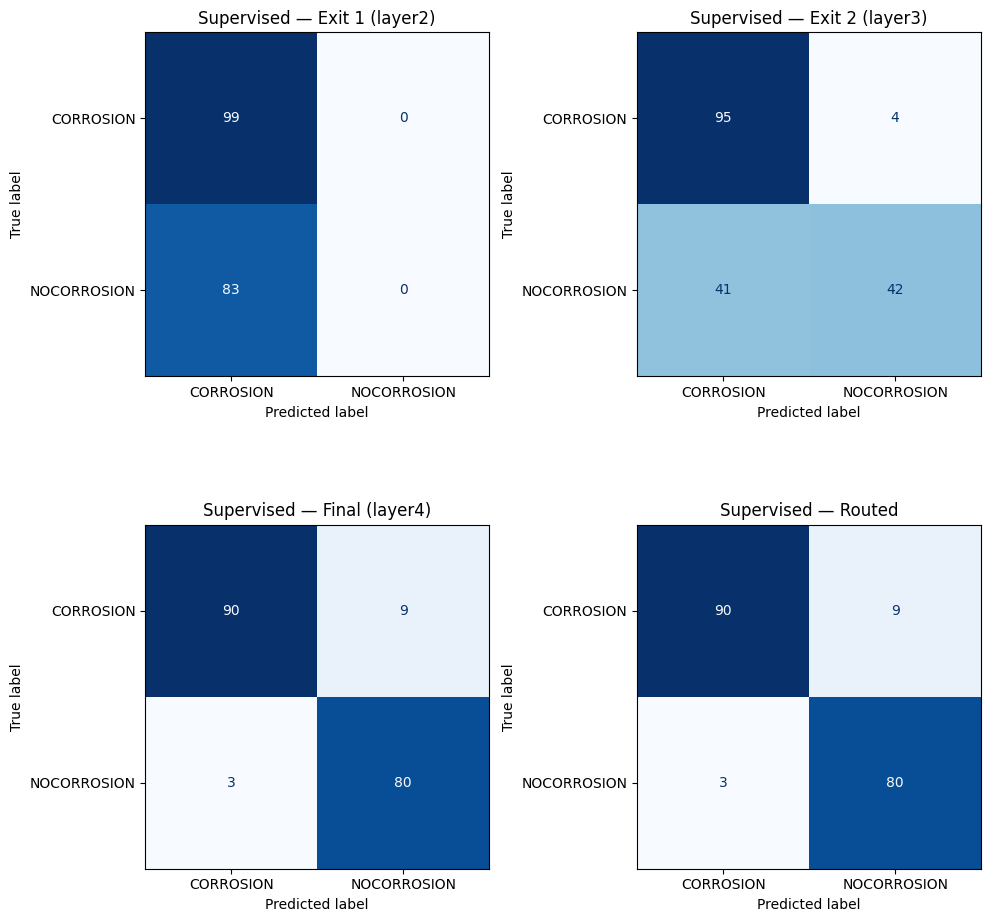

In [116]:
def get_all_exit_predictions(dataloader, tau1=0.90, tau2=0.90):
    backbone.eval(); exit1_head.eval(); exit2_head.eval(); final_head.eval()
    y_true, y_exit1, y_exit2, y_final, y_routed = [], [], [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            e1, e2, ef = forward_early_exit(inputs)
            p1 = torch.softmax(e1, 1); c1, pred1 = p1.max(1)
            p2 = torch.softmax(e2, 1); c2, pred2 = p2.max(1)
            predf = ef.argmax(1)

            routed = []
            for i in range(labels.size(0)):
                if   c1[i] >= tau1: routed.append(pred1[i].item())
                elif c2[i] >= tau2: routed.append(pred2[i].item())
                else:               routed.append(predf[i].item())

            y_true.extend(labels.cpu().numpy())
            y_exit1.extend(pred1.cpu().numpy())
            y_exit2.extend(pred2.cpu().numpy())
            y_final.extend(predf.cpu().numpy())
            y_routed.extend(routed)

    return y_true, y_exit1, y_exit2, y_final, y_routed

y_true, y_exit1, y_exit2, y_final, y_routed = get_all_exit_predictions(test_loader, tau1=0.90, tau2=0.90)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for (title, preds, ax) in [
    ('Exit 1 (layer2)', y_exit1, axes[0,0]),
    ('Exit 2 (layer3)', y_exit2, axes[0,1]),
    ('Final (layer4)',  y_final, axes[1,0]),
    ('Routed',          y_routed, axes[1,1]),
]:
    cm = confusion_matrix(y_true, preds)
    ConfusionMatrixDisplay(cm, display_labels=train_ds.classes).plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'Supervised — {title}')
plt.tight_layout(); plt.savefig('sup_ee_confusion.png', dpi=150); plt.show()

### Exit Rates and Accuracy vs Threshold

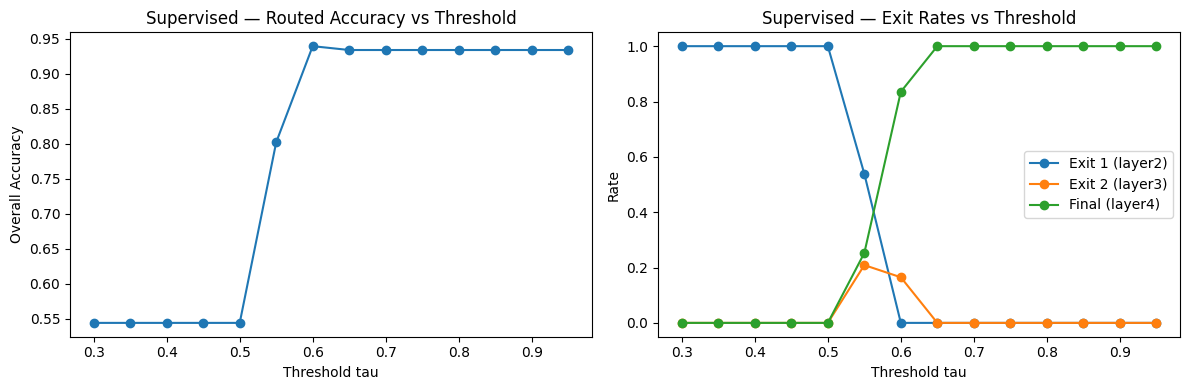

Results saved to sup_ee_results.json


In [117]:
taus        = [x[0] for x in sup_results]
accs        = [x[1] for x in sup_results]
exit1_rates = [x[2] for x in sup_results]
exit2_rates = [x[3] for x in sup_results]
final_rates = [x[4] for x in sup_results]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(taus, accs, marker='o'); plt.xlabel('Threshold tau'); plt.ylabel('Overall Accuracy')
plt.title('Supervised — Routed Accuracy vs Threshold')

plt.subplot(1, 2, 2)
plt.plot(taus, exit1_rates, marker='o', label='Exit 1 (layer2)')
plt.plot(taus, exit2_rates, marker='o', label='Exit 2 (layer3)')
plt.plot(taus, final_rates, marker='o', label='Final (layer4)')
plt.xlabel('Threshold tau'); plt.ylabel('Rate'); plt.legend()
plt.title('Supervised — Exit Rates vs Threshold')
plt.tight_layout(); plt.savefig('sup_ee_rates.png', dpi=150); plt.show()

import json
with open('sup_ee_results.json', 'w') as f:
    json.dump(sup_results, f)
print('Results saved to sup_ee_results.json')

---
# Section 3 — Comparison: SimCLR vs Supervised

# Early Exit Comparison: SimCLR vs Supervised
Loads saved results from both early exit notebooks and compares accuracy, exit rates, and efficiency across thresholds.

**Run `early_exit_simclr.ipynb` and `early_exit_supervised.ipynb` first** to generate the `.json` and `.pt` result files.

In [118]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from pathlib import Path
import torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

with open('simclr_ee_results.json') as f:
    simclr_results = json.load(f)
with open('sup_ee_results.json') as f:
    sup_results = json.load(f)

print('SimCLR results loaded:', len(simclr_results), 'thresholds')
print('Supervised results loaded:', len(sup_results), 'thresholds')

Device: mps
SimCLR results loaded: 14 thresholds
Supervised results loaded: 14 thresholds


### Accuracy vs Threshold

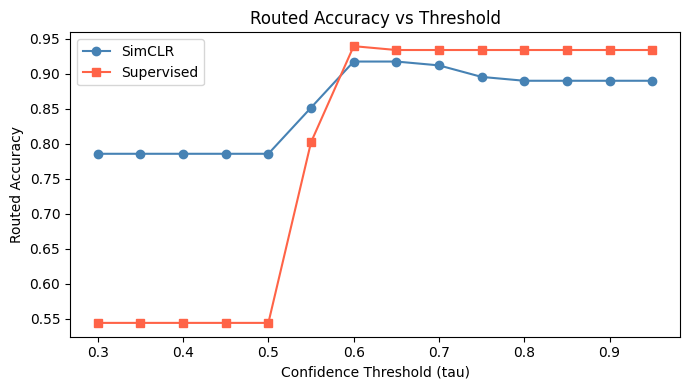

In [119]:
taus        = [x[0] for x in simclr_results]
simclr_accs = [x[1] for x in simclr_results]
sup_accs    = [x[1] for x in sup_results]

plt.figure(figsize=(7, 4))
plt.plot(taus, simclr_accs, 'o-', label='SimCLR', color='steelblue')
plt.plot(taus, sup_accs,    's-', label='Supervised', color='tomato')
plt.xlabel('Confidence Threshold (tau)')
plt.ylabel('Routed Accuracy')
plt.title('Routed Accuracy vs Threshold')
plt.legend(); plt.tight_layout()
plt.savefig('compare_accuracy.png', dpi=150); plt.show()

### Early Exit Rate vs Threshold

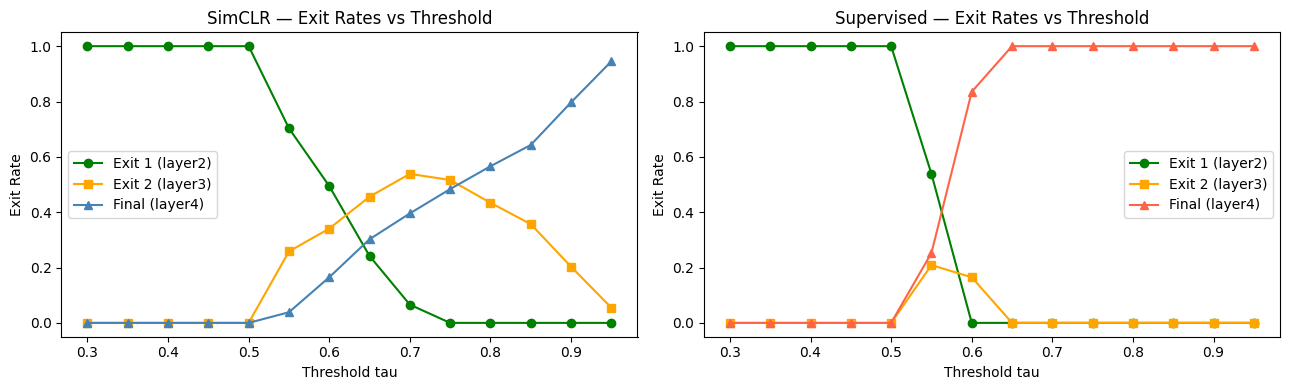

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, results, name, color in [
    (axes[0], simclr_results, 'SimCLR',     'steelblue'),
    (axes[1], sup_results,    'Supervised', 'tomato'),
]:
    taus = [x[0] for x in results]
    ax.plot(taus, [x[2] for x in results], 'o-', label='Exit 1 (layer2)', color='green')
    ax.plot(taus, [x[3] for x in results], 's-', label='Exit 2 (layer3)', color='orange')
    ax.plot(taus, [x[4] for x in results], '^-', label='Final (layer4)',  color=color)
    ax.set_xlabel('Threshold tau'); ax.set_ylabel('Exit Rate')
    ax.set_title(f'{name} — Exit Rates vs Threshold')
    ax.legend()

plt.tight_layout(); plt.savefig('compare_exit_rates.png', dpi=150); plt.show()

### Summary Table (tau=0.90)

In [121]:
import pandas as pd

rows = []
for results, name in [(simclr_results, 'SimCLR'), (sup_results, 'Supervised')]:
    # Find tau=0.90
    r = next(x for x in results if abs(x[0] - 0.90) < 0.001)
    rows.append({
        'Model':         name,
        'Accuracy':      f'{r[1]:.4f}',
        'Exit1 Rate':    f'{r[2]:.4f}',
        'Exit2 Rate':    f'{r[3]:.4f}',
        'Final Rate':    f'{r[4]:.4f}',
        'Early Exit %':  f'{(r[2]+r[3])*100:.1f}%',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

     Model Accuracy Exit1 Rate Exit2 Rate Final Rate Early Exit %
    SimCLR   0.8901     0.0000     0.2033     0.7967        20.3%
Supervised   0.9341     0.0000     0.0000     1.0000         0.0%


### Accuracy vs Early Exit Rate (efficiency frontier)

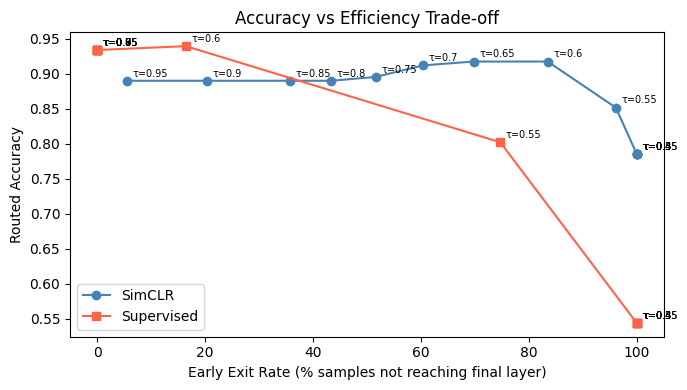

In [122]:
plt.figure(figsize=(7, 4))

for results, name, color, marker in [
    (simclr_results, 'SimCLR',     'steelblue', 'o'),
    (sup_results,    'Supervised', 'tomato',    's'),
]:
    early_pcts = [(x[2]+x[3])*100 for x in results]
    accs       = [x[1] for x in results]
    taus_lbl   = [x[0] for x in results]
    plt.plot(early_pcts, accs, marker+'-', color=color, label=name)
    for ep, ac, tau in zip(early_pcts, accs, taus_lbl):
        plt.annotate(f'τ={tau}', (ep, ac), textcoords='offset points', xytext=(4, 3), fontsize=7)

plt.xlabel('Early Exit Rate (% samples not reaching final layer)')
plt.ylabel('Routed Accuracy')
plt.title('Accuracy vs Efficiency Trade-off')
plt.legend(); plt.tight_layout()
plt.savefig('compare_frontier.png', dpi=150); plt.show()

### run side by sied on test set

In [123]:
test_dir = Path('dataset_ood/test')
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_ds     = ImageFolder(test_dir, transform=val_tfms)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
num_classes = len(test_ds.classes)
print('Classes:', test_ds.classes)

Classes: ['CORROSION', 'NOCORROSION']


In [124]:
def build_backbone_and_heads(num_classes, device):
    backbone   = models.resnet18(weights=None)
    backbone.fc = nn.Identity()
    backbone    = backbone.to(device)
    exit1_head = nn.Sequential(nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(), nn.Linear(128, num_classes)).to(device)
    exit2_head = nn.Sequential(nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(), nn.Linear(256, num_classes)).to(device)
    final_head = nn.Linear(512, num_classes).to(device)
    return backbone, exit1_head, exit2_head, final_head

def load_ee_checkpoint(path, num_classes, device):
    bb, e1, e2, ef = build_backbone_and_heads(num_classes, device)
    ckpt = torch.load(path, map_location=device)
    bb.load_state_dict(ckpt['backbone'])
    e1.load_state_dict(ckpt['exit1_head'])
    e2.load_state_dict(ckpt['exit2_head'])
    ef.load_state_dict(ckpt['final_head'])
    for m in [bb, e1, e2, ef]: m.eval()
    return bb, e1, e2, ef

def make_forward(bb):
    def forward_early_exit(x):
        x = bb.conv1(x); x = bb.bn1(x); x = bb.relu(x); x = bb.maxpool(x)
        x = bb.layer1(x); x = bb.layer2(x); e1 = None  # filled below
        return x
    return forward_early_exit

def evaluate_model(backbone, exit1_head, exit2_head, final_head, dataloader, tau1=0.90, tau2=0.90):
    for m in [backbone, exit1_head, exit2_head, final_head]: m.eval()
    total = correct = c1 = c2 = cf = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            x = backbone.conv1(inputs); x = backbone.bn1(x); x = backbone.relu(x); x = backbone.maxpool(x)
            x = backbone.layer1(x)
            x = backbone.layer2(x); e1_logits = exit1_head(x)
            x = backbone.layer3(x); e2_logits = exit2_head(x)
            x = backbone.layer4(x); x = backbone.avgpool(x); x = torch.flatten(x, 1)
            ef_logits = final_head(x)

            p1 = torch.softmax(e1_logits, 1); conf1, pred1 = p1.max(1)
            p2 = torch.softmax(e2_logits, 1); conf2, pred2 = p2.max(1)
            predf = ef_logits.argmax(1)

            batch_preds = []
            for i in range(labels.size(0)):
                if   conf1[i] >= tau1: batch_preds.append(pred1[i].item()); c1 += 1
                elif conf2[i] >= tau2: batch_preds.append(pred2[i].item()); c2 += 1
                else:                  batch_preds.append(predf[i].item()); cf += 1

            bt = torch.tensor(batch_preds, device=labels.device)
            correct += (bt == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(batch_preds)
            all_labels.extend(labels.cpu().numpy())

    return correct/total, c1/total, c2/total, cf/total, all_preds, all_labels

# Load both models
bb_s, e1_s, e2_s, ef_s = load_ee_checkpoint('early_exit_simclr.pt',     num_classes, DEVICE)
bb_p, e1_p, e2_p, ef_p = load_ee_checkpoint('early_exit_supervised.pt', num_classes, DEVICE)
print('Both models loaded.')

Both models loaded.


In [125]:
TAU = 0.90
acc_s, r1_s, r2_s, rf_s, preds_s, labels_s = evaluate_model(bb_s, e1_s, e2_s, ef_s, test_loader, TAU, TAU)
acc_p, r1_p, r2_p, rf_p, preds_p, labels_p = evaluate_model(bb_p, e1_p, e2_p, ef_p, test_loader, TAU, TAU)

print(f'\nSimCLR     — acc={acc_s:.4f} | exit1={r1_s:.4f} | exit2={r2_s:.4f} | final={rf_s:.4f}')
print(f'Supervised — acc={acc_p:.4f} | exit1={r1_p:.4f} | exit2={r2_p:.4f} | final={rf_p:.4f}')


SimCLR     — acc=0.8901 | exit1=0.0000 | exit2=0.2033 | final=0.7967
Supervised — acc=0.9341 | exit1=0.0000 | exit2=0.0000 | final=1.0000


### Confusion matrices (tau=0.90)

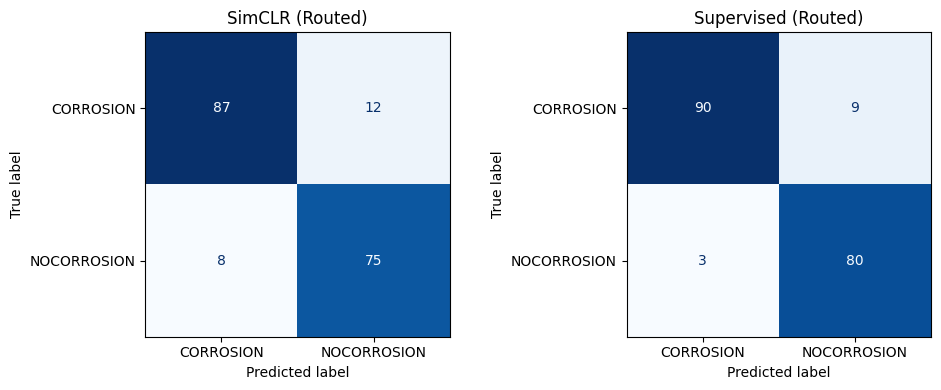

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, labels, name in [
    (axes[0], preds_s, labels_s, 'SimCLR (Routed)'),
    (axes[1], preds_p, labels_p, 'Supervised (Routed)'),
]:
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(cm, display_labels=test_ds.classes).plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig('compare_confusion.png', dpi=150); plt.show()

	                                SimCLR	Supervised
Test accuracy (routed)	       |    95.6%	95.1%

Early exit rate (tau=0.90)	   |    46.7%	0%

Val final acc	               |    89.3%	91.1%

Best for deployment efficiency |	  YES	No

Best raw accuracy	           |       No	Marginal

SimCLR better for deplyment: skip easier samples while keeping decent accuracy